In [ ]:
import pandas as pd
import numpy as np


# Data Handling

In [ ]:
raw_df = pd.read_csv("/content/booking.csv")

In [ ]:
raw_df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [ ]:
raw_df.isnull().sum()

,0
Booking_ID,0
number of adults,0
number of children,0
number of weekend nights,0
number of week nights,0
type of meal,0
car parking space,0
room type,0
lead time,0
market segment type,0


In [ ]:
raw_df.duplicated().sum()

np.int64(0)

In [ ]:
raw_df.shape

(36285, 17)

In [ ]:
# Drop unwanted columns

new_df = raw_df.drop(['Booking_ID', 'date of reservation'], axis=1)

new_df.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,Not_Canceled
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,Canceled
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,Canceled
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,Canceled


In [ ]:
new_df.shape

(36285, 15)

In [ ]:
new_df.select_dtypes(include='object').columns

Index(['type of meal', 'room type', 'market segment type', 'booking status'], dtype='object')

# Visualisation for finding Outliers and Correlation

## Outliers

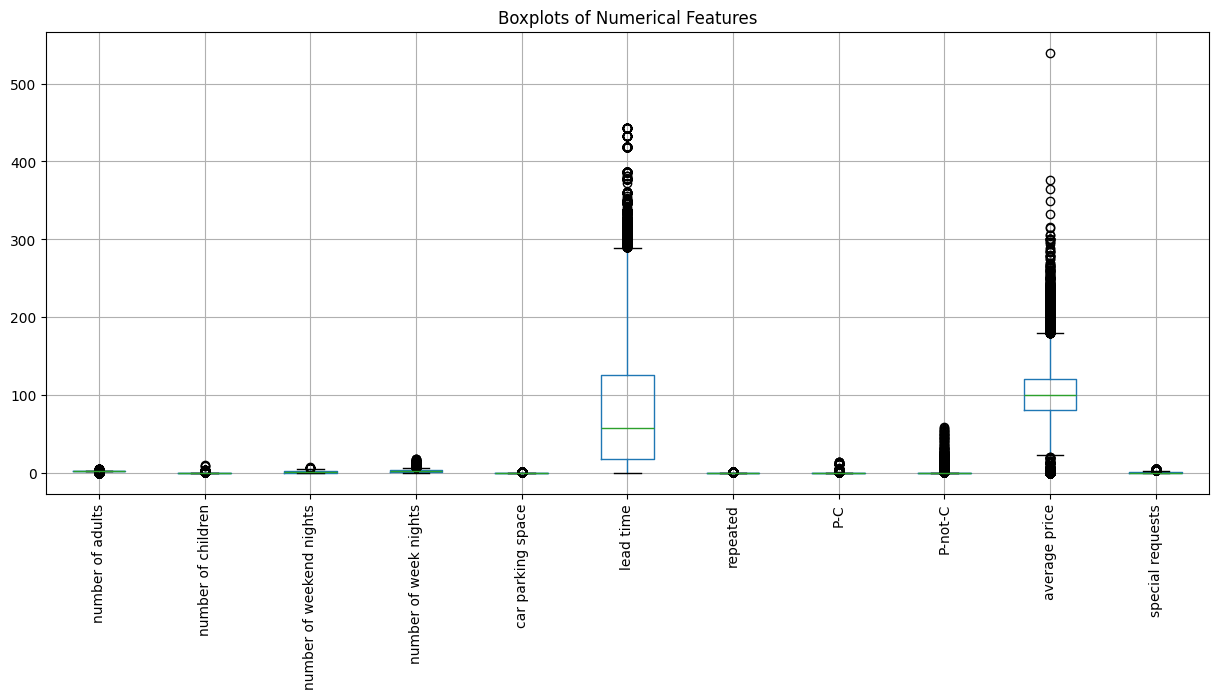

In [ ]:
# checking for outliers in the numerical columns

import matplotlib.pyplot as plt

new_df.boxplot(figsize=(15,6), rot=90)

plt.title("Boxplots of Numerical Features")
plt.show()

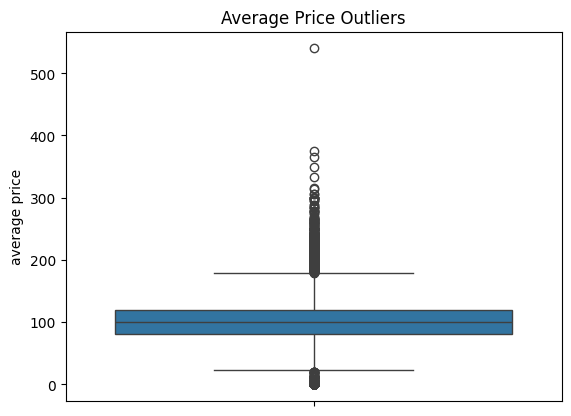

In [ ]:
import seaborn as sns

sns.boxplot(y=new_df['average price'])

plt.title("Average Price Outliers")
plt.show()

In [ ]:
# counting the number of outliers

Q1 = new_df['average price'].quantile(0.25)
Q3 = new_df['average price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = new_df[(new_df['average price'] < lower) |
              (new_df['average price'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 1696


In [ ]:
# # keeping outliers for now until the models scores are found

## Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

new_df['type of meal'] = le.fit_transform(new_df['type of meal'])
new_df['room type'] = le.fit_transform(new_df['room type'])
new_df['market segment type'] = le.fit_transform(new_df['market segment type'])
new_df['booking status'] = le.fit_transform(new_df['booking status'])

# or use for loop for simpler code

# new_df = new_df.apply(
#     lambda col: LabelEncoder().fit_transform(col)
#     if col.dtype == 'object'
#     else col
# )

In [ ]:
new_df.dtypes

,0
number of adults,int64
number of children,int64
number of weekend nights,int64
number of week nights,int64
type of meal,int64
car parking space,int64
room type,int64
lead time,int64
market segment type,int64
repeated,int64


## Correlation

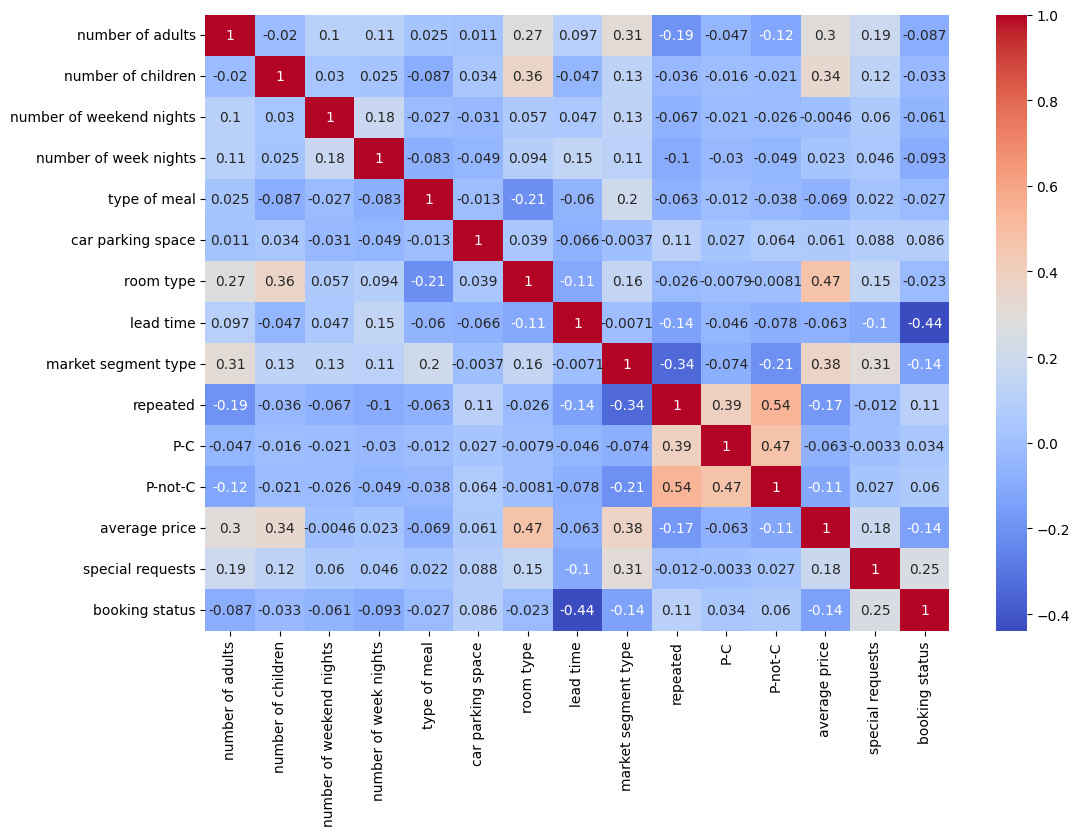

In [ ]:

plt.figure(figsize=(12,8))

sns.heatmap(
    new_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
print(new_df.corr()['booking status'].sort_values(ascending=False))

booking status              1.000000
special requests            0.253092
repeated                    0.107277
car parking space           0.086179
P-not-C                     0.060174
P-C                         0.033725
room type                  -0.022877
type of meal               -0.026772
number of children         -0.033007
number of weekend nights   -0.061489
number of adults           -0.086774
number of week nights      -0.092824
market segment type        -0.136005
average price              -0.142433
lead time                  -0.438491
Name: booking status, dtype: float64


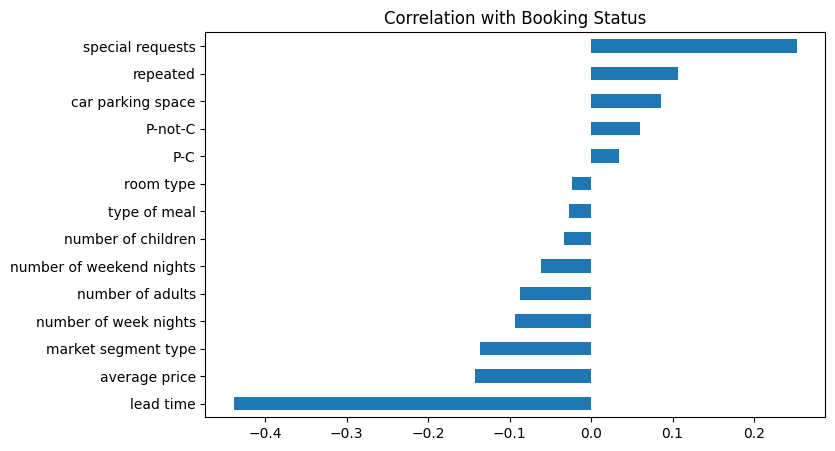

In [ ]:
corr_booking = new_df.corr()['booking status'].drop('booking status')

corr_booking.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Correlation with Booking Status')
plt.show()

In [ ]:
# Strongest predictors for booking status is a negative corelation from lead time and positive corelation from special request

In [ ]:
print(new_df.corr()['average price'].sort_values(ascending=False))

average price               1.000000
room type                   0.469908
market segment type         0.375597
number of children          0.337491
number of adults            0.296832
special requests            0.184468
car parking space           0.061310
number of week nights       0.022751
number of weekend nights   -0.004565
lead time                  -0.062578
P-C                        -0.063334
type of meal               -0.069268
P-not-C                    -0.113673
booking status             -0.142433
repeated                   -0.174881
Name: average price, dtype: float64


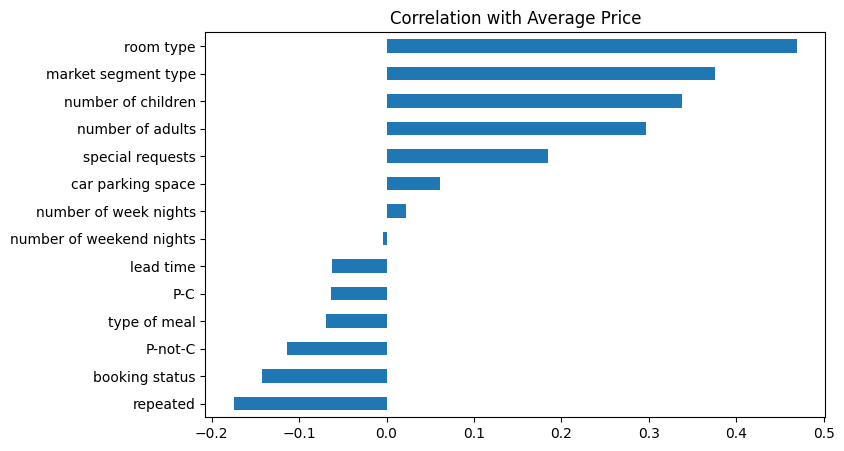

In [ ]:
corr_price = new_df.corr()['average price'].drop('average price')

corr_price.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Correlation with Average Price')
plt.show()

In [ ]:
# Strongest predictors for average price are positive corelation from room type, market segment type, number of children, number of adults

# Random Forest Classifier (Booking Status)

## Splitting

In [ ]:
X = new_df.drop('booking status', axis=1)

y = new_df['booking status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(29028, 14)
(7257, 14)
(29028,)
(7257,)


## Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# n_estimators=20, max_depth=10

In [ ]:
rf.get_params(deep=True)

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
y_pred = rf.predict(X_test)

## Evaluation (Accuracy, Confusion Matrix and Classification Report)

In [ ]:
# Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8886592255753066


In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1894  508]
 [ 300 4555]]


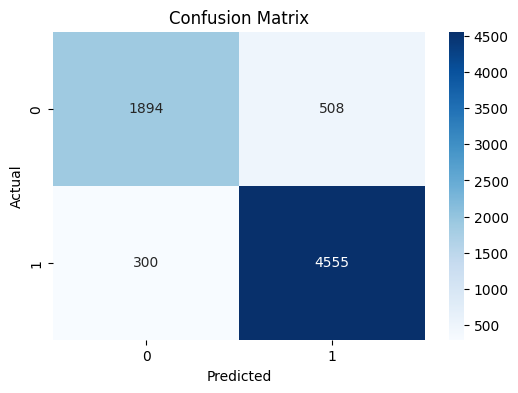

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82      2402
           1       0.90      0.94      0.92      4855

    accuracy                           0.89      7257
   macro avg       0.88      0.86      0.87      7257
weighted avg       0.89      0.89      0.89      7257



# Multiple Linear Regression (Average Price)

## Splitting

In [ ]:
X_reg = new_df.drop('average price', axis=1)
y_reg = new_df['average price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train_reg.shape)
print(X_test_reg.shape)

print(y_train_reg.shape)
print(y_test_reg.shape)

(29028, 14)
(7257, 14)
(29028,)
(7257,)


## Model Training

In [ ]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()

mlr.fit(X_train_reg, y_train_reg)

LinearRegression()

In [ ]:
y_pred_reg = mlr.predict(X_test_reg)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R² Score: 0.3882549632075839
MAE: 20.267667046776985
RMSE: 27.24718226954114


In [ ]:
# low R2 - hence trying Random Forest Regressor for same train-test data

## Random Forest Regressor (Average Price)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=42)

rf_reg.fit(X_train_reg, y_train_reg)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf_reg.predict(X_test_reg)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2_rf = r2_score(y_test_reg, y_pred_rf)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))

print("R² Score:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

R² Score: 0.6365598400334868
MAE: 13.276461081686936
RMSE: 21.001621500011527


In [ ]:
# Random Forest Regressor explains around 63.7% of the variation in average price (compared to only 38.8% for Multiple Linear Regression).
# MAE decreased from 20.27 to 13.28, hence predictions are closer to the actual prices.
# RMSE decreased from 27.25 to 21.00, indicating fewer large prediction errors.